# Task 4: Model Evaluation and Error Analysis

I  am using this notebook for task for this compares the Random Forest and Logistic Regression multi-output classifiers using the saved evaluation results. It examines overall performance, per-label performance, class imbalance, and genuine misclassification examples.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

OUTPUTS = PROJECT_ROOT / "outputs"

print(f"Project root: {PROJECT_ROOT}")
print(f"Outputs directory: {OUTPUTS}")

Project root: c:\Users\josep\Desktop\CA_Code_Starter\CA_Code_Starter
Outputs directory: c:\Users\josep\Desktop\CA_Code_Starter\CA_Code_Starter\outputs


## 4.1 Load the evaluation outputs

The notebook reuses the JSON and CSV files generated by the training pipeline to provide an evaluation and analysis of the results

In [2]:
def load_json(path):
    with open(path, encoding="utf-8") as file:
        return json.load(file)


results = {
    "Random Forest": load_json(
        OUTPUTS / "metrics_random_forest.json"
    ),
    "Logistic Regression": load_json(
        OUTPUTS / "metrics_logistic_regression.json"
    ),
}

reports = {
    "Random Forest": pd.read_csv(
        OUTPUTS / "classification_report_random_forest.csv"
    ),
    "Logistic Regression": pd.read_csv(
        OUTPUTS / "classification_report_logistic_regression.csv"
    ),
}

errors = {
    "Random Forest": pd.read_csv(
        OUTPUTS / "errors_random_forest.csv"
    ),
    "Logistic Regression": pd.read_csv(
        OUTPUTS / "errors_logistic_regression.csv"
    ),
}

print("Evaluation files loaded successfully.")

Evaluation files loaded successfully.


## 4.2 Overall model comparison

- **Hamming loss** is the proportion of individual label decisions that are incorrect this inturn means that the low the Hamming loss the better
- **Exact-match accuracy** is the proportion of messages for which all three labels are correct.
- **Mean macro F1** is the average macro F1 across `y2`, `y3`, and `y4`.

In [3]:
overall_rows = []

for model_name, result in results.items():
    overall_rows.append({
        "Model": model_name,
        "Test samples": result["n_test_samples"],
        "Hamming loss": result["overall"]["hamming_loss"],
        "Exact-match accuracy": result["overall"]["exact_match_accuracy"],
        "Mean macro F1": result["overall"]["mean_f1_macro"],
    })

overall_df = pd.DataFrame(overall_rows)
overall_df = overall_df.sort_values(
    "Mean macro F1", ascending=False
).reset_index(drop=True)

display(overall_df.style.format({
    "Hamming loss": "{:.3f}",
    "Exact-match accuracy": "{:.3f}",
    "Mean macro F1": "{:.3f}",
}).highlight_max(
    subset=["Exact-match accuracy", "Mean macro F1"],
    color=""
).highlight_min(
    subset=["Hamming loss"],
    color=""
))

,Model,Test samples,Hamming loss,Exact-match accuracy,Mean macro F1
0,Random Forest,42,0.325,0.524,0.525
1,Logistic Regression,42,0.429,0.405,0.464


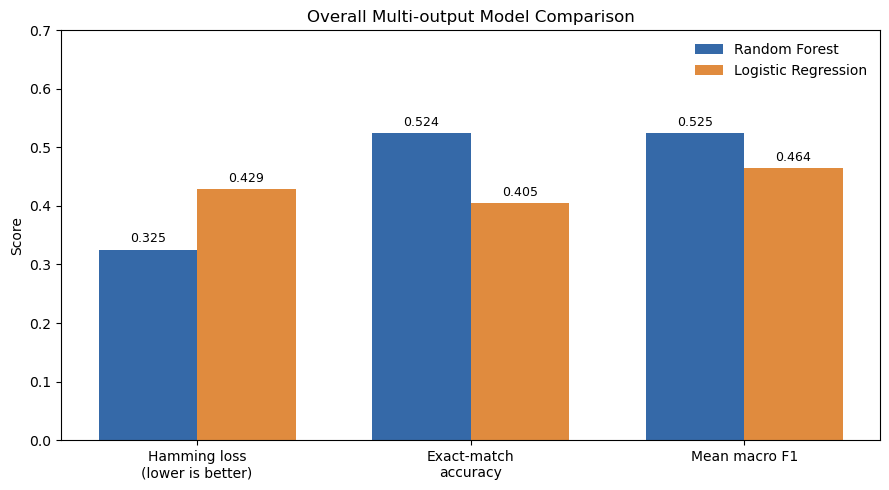

In [4]:
metrics = [
    "Hamming loss",
    "Exact-match accuracy",
    "Mean macro F1",
]

metric_labels = [
    "Hamming loss\n(lower is better)",
    "Exact-match\naccuracy",
    "Mean macro F1",
]

positions = np.arange(len(metrics))
width = 0.36
colours = ["#3569a8", "#e08b3e"]

fig, ax = plt.subplots(figsize=(9, 5))

for index, row in overall_df.iterrows():
    offset = (index - 0.5) * width
    values = row[metrics].astype(float).to_numpy()

    bars = ax.bar(
        positions + offset,
        values,
        width,
        label=row["Model"],
        color=colours[index],
    )

    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)

ax.set_title("Overall Multi-output Model Comparison")
ax.set_ylabel("Score")
ax.set_xticks(positions, metric_labels)
ax.set_ylim(0, 0.70)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### Overall interpretation

Random Forest performs better overall. It has a lower Hamming loss, by having a lower Hamming loss it means that it makes fewer incorrect individual label decisions. It also has a higher exact-match accuracy and mean macro F1. This makes Random Forest to be selected as the preferred model for the current prototype.

## 4.3 Per-label results

The following table compares performance separately for `y2`, `y3`, and `y4`. Macro metrics assign equal importance to every class, including rare classes.

In [5]:
label_rows = []

for model_name, result in results.items():
    for label, metric in result["per_label"].items():
        label_rows.append({
            "Model": model_name,
            "Label": label,
            "Classes": metric["n_classes"],
            "Accuracy": metric["accuracy"],
            "Macro precision": metric["precision_macro"],
            "Macro recall": metric["recall_macro"],
            "Macro F1": metric["f1_macro"],
            "Weighted F1": metric["f1_weighted"],
        })

per_label_df = pd.DataFrame(label_rows)
per_label_df = per_label_df.sort_values(
    ["Label", "Model"]
).reset_index(drop=True)

metric_columns = [
    "Accuracy",
    "Macro precision",
    "Macro recall",
    "Macro F1",
    "Weighted F1",
]

display(per_label_df.style.format(
    {column: "{:.3f}" for column in metric_columns}
))

,Model,Label,Classes,Accuracy,Macro precision,Macro recall,Macro F1,Weighted F1
0,Logistic Regression,y2,3,0.714,0.687,0.686,0.685,0.716
1,Random Forest,y2,3,0.738,0.817,0.647,0.662,0.720
2,Logistic Regression,y3,11,0.500,0.375,0.448,0.369,0.514
3,Random Forest,y3,11,0.643,0.499,0.488,0.482,0.650
4,Logistic Regression,y4,14,0.500,0.349,0.400,0.338,0.507
5,Random Forest,y4,14,0.643,0.426,0.455,0.431,0.603


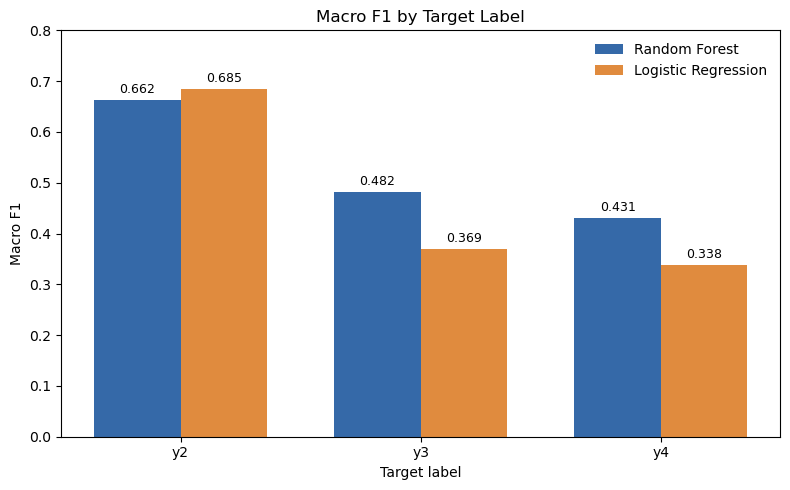

In [6]:
labels = ["y2", "y3", "y4"]
models = list(results)
positions = np.arange(len(labels))
width = 0.36
colours = ["#3569a8", "#e08b3e"]

fig, ax = plt.subplots(figsize=(8, 5))

for index, model_name in enumerate(models):
    model_rows = (
        per_label_df[per_label_df["Model"] == model_name]
        .set_index("Label")
        .loc[labels]
    )

    offset = (index - 0.5) * width

    bars = ax.bar(
        positions + offset,
        model_rows["Macro F1"],
        width,
        label=model_name,
        color=colours[index],
    )

    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)

ax.set_title("Macro F1 by Target Label")
ax.set_xlabel("Target label")
ax.set_ylabel("Macro F1")
ax.set_xticks(positions, labels)
ax.set_ylim(0, 0.8)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### Per-label interpretation

`y2` is the easiest target because it contains only three classes. Performance decreases for `y3` and `y4`, which contain 11 and 14 classes. Random Forest performs way better because they are more detailed targets. Logistic Regression has a slightly higher macro F1 for `y2`, despite Random Forest having higher `y2` accuracy. This shows us why accuracy and macro F1 should be considered together as accuracy doesn't tell the full story

## 4.4 Class-imbalance analysis

Weighted F1 gives greater influence to frequent classes, while macro F1 treats every class equally. A large difference between the two metrics that common classes are being classified more successfully than rare classes.

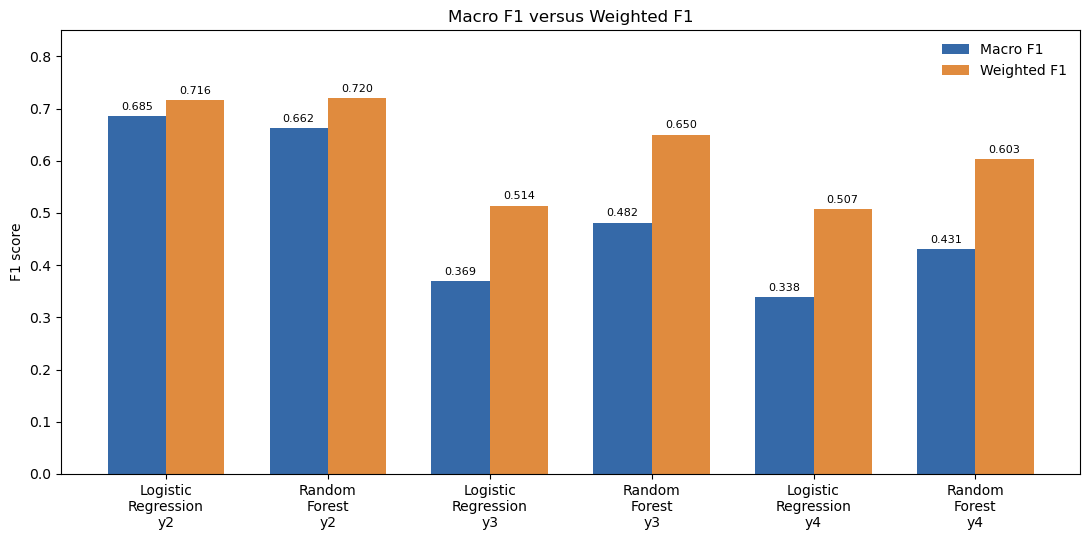

In [7]:
chart_df = per_label_df.copy()
chart_df["Display name"] = (
    chart_df["Model"].str.replace(" ", "\n")
    + "\n"
    + chart_df["Label"]
)

positions = np.arange(len(chart_df))
width = 0.36

fig, ax = plt.subplots(figsize=(11, 5.5))

macro_bars = ax.bar(
    positions - width / 2,
    chart_df["Macro F1"],
    width,
    label="Macro F1",
    color="#3569a8",
)

weighted_bars = ax.bar(
    positions + width / 2,
    chart_df["Weighted F1"],
    width,
    label="Weighted F1",
    color="#e08b3e",
)

ax.bar_label(macro_bars, fmt="%.3f", padding=3, fontsize=8)
ax.bar_label(weighted_bars, fmt="%.3f", padding=3, fontsize=8)

ax.set_title("Macro F1 versus Weighted F1")
ax.set_ylabel("F1 score")
ax.set_xticks(positions, chart_df["Display name"])
ax.set_ylim(0, 0.85)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### Imbalance interpretation

The  reason weighted F1 is higher than macro is F1 for most target, You can see the difference clearly between `y3` and`y4`, as it reinstates that frequent classes perform reasonably well while rare calasses reduce the macro average. Class weighting helps to reduce majority-class bias, but it doesn't create enough learning evidence for classes that have only a few training examples.


## 4.5 Random Forest per-class results

The full classification report can be filtered by target. The `y2` results provide a clear example of minority-class behaviour.

In [8]:
rf_report = reports["Random Forest"]

rf_y2 = rf_report[
    (rf_report["label"] == "y2")
    & (~rf_report["class"].isin(["macro avg", "weighted avg"]))
].copy()

display(rf_y2.style.format({
    "precision": "{:.3f}",
    "recall": "{:.3f}",
    "f1": "{:.3f}",
}))

,label,class,precision,recall,f1,support
0,y2,Others,1.000,0.286,0.444,7
1,y2,Problem/Fault,0.650,0.812,0.722,16
2,y2,Suggestion,0.800,0.842,0.821,19


The `Others` class has high precision but low recall. This means that when Random Forest predicts `Others`, it is usually correct, but it misses most of the genuine `Others` messages. This is a typical minority-class failure: the model is conservative about assigning the less frequent class.

## 4.6 Error analysis

The error files contain genuine incorrect predictions from the test set. Each row represents one incorrect target-label decision.

In [9]:
error_summary_rows = []

for model_name, error_df in errors.items():
    counts = error_df["label"].value_counts()

    for label in ["y2", "y3", "y4"]:
        error_summary_rows.append({
            "Model": model_name,
            "Label": label,
            "Errors in saved file": int(counts.get(label, 0)),
        })

error_summary_df = pd.DataFrame(error_summary_rows)
display(error_summary_df)

,Model,Label,Errors in saved file
0,Random Forest,y2,11
1,Random Forest,y3,15
2,Random Forest,y4,15
3,Logistic Regression,y2,12
4,Logistic Regression,y3,21
5,Logistic Regression,y4,17


In [10]:
print("Random Forest error examples")

display(
    errors["Random Forest"][[
        "row_index",
        "text_snippet",
        "label",
        "true",
        "predicted",
    ]].head(15)
)

Random Forest error examples


,row_index,text_snippet,label,true,predicted
0,65,NaN,y2,Others,Problem/Fault
1,68,how do become vip if do saw if it right you ha...,y2,Problem/Fault,Suggestion
2,6,so the campaign name was xmas download and win...,y2,Suggestion,Problem/Fault
3,131,product cloud requests upgrade cloud storage c...,y2,Suggestion,Problem/Fault
4,63,NaN,y2,Others,Problem/Fault
5,125,this is the mail system at host frasgout his c...,y2,Others,Suggestion
6,20,beskrivelse installation fejl kontaktoplysninger,y2,Problem/Fault,Suggestion
7,41,we hope you re doing well description of the i...,y2,Others,Problem/Fault
8,117,we are bringing you an answer regarding your c...,y2,Problem/Fault,Suggestion
9,3,description contact information,y2,Suggestion,Problem/Fault


### Error interpretation

The errors show several recurring causes:
- Some messages are openly phrased questions this is hard to interpret and define properly.
- Some of the interactions do not contain enough evidence to where they can be properly classified.
- Related categories share vocabulary, such as VIP promotions and payments.
-Classes outside the training split cannot be learned reliably predicted
- Some interaction content becomes empty after preprocessing.

The most serious observed error is a refund request classified as a payment issue. Refund requests may be time-sensitive and require a specialised queue. Low-confidence predictions and high-risk categories should be routed for human review.

## 4.7 Limitations
- The set is too small, since there's only 42 messages a small number of changed predictions will noticeably affect the results.
- The evaluation uses a single train/test split rather than cross-validation.
- Because stratification is based on in `y2` and not `y3` and `y4` it doesn't ensure rare classes occur in both partitions.
- Some classes occur only in the test split and are impossible for the trained models to predict correctly.
- Missing secondary labels are represented by the `unknown` sentinel.
- Preprocessing steps frequently strip away contextual markers and distinct syntactic features may reduce the available TF-IDF signal.
- Offline metrics do not directly measure operational effects such as routing delays or escalation rates.


## 4.8 Conclusion

Random Forest is the preferred model for the current prototype because it achieves the highest mean macro F1 and exact-match accuracy and the lowest Hamming loss. But both of the models perform less effectively on detailed, rare, and unseen classes. Production use should include confidence-based human review, monitoring, and collection of additional labelled examples.

In [11]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 100)

# Works when launched from either the project root or notebooks/.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

OUTPUTS = PROJECT_ROOT / "outputs"

print(f"Project root: {PROJECT_ROOT}")
print(f"Outputs directory: {OUTPUTS}")

Project root: c:\Users\josep\Desktop\CA_Code_Starter\CA_Code_Starter
Outputs directory: c:\Users\josep\Desktop\CA_Code_Starter\CA_Code_Starter\outputs


## 4.1 Load the evaluation outputs

The notebook reuses the JSON and CSV files generated by the training pipeline. It does not retrain either model.

In [12]:
def load_json(path):
    with open(path, encoding="utf-8") as file:
        return json.load(file)


results = {
    "Random Forest": load_json(
        OUTPUTS / "metrics_random_forest.json"
    ),
    "Logistic Regression": load_json(
        OUTPUTS / "metrics_logistic_regression.json"
    ),
}

reports = {
    "Random Forest": pd.read_csv(
        OUTPUTS / "classification_report_random_forest.csv"
    ),
    "Logistic Regression": pd.read_csv(
        OUTPUTS / "classification_report_logistic_regression.csv"
    ),
}

errors = {
    "Random Forest": pd.read_csv(
        OUTPUTS / "errors_random_forest.csv"
    ),
    "Logistic Regression": pd.read_csv(
        OUTPUTS / "errors_logistic_regression.csv"
    ),
}

print("Evaluation files loaded successfully.")

Evaluation files loaded successfully.


## 4.2 Overall model comparison

- **Hamming loss** is the proportion of individual label decisions that are incorrect. Lower is better.
- **Exact-match accuracy** is the proportion of messages for which all three labels are correct.
- **Mean macro F1** is the average macro F1 across `y2`, `y3`, and `y4`.

In [13]:
overall_rows = []

for model_name, result in results.items():
    overall_rows.append({
        "Model": model_name,
        "Test samples": result["n_test_samples"],
        "Hamming loss": result["overall"]["hamming_loss"],
        "Exact-match accuracy": result["overall"]["exact_match_accuracy"],
        "Mean macro F1": result["overall"]["mean_f1_macro"],
    })

overall_df = pd.DataFrame(overall_rows)
overall_df = overall_df.sort_values(
    "Mean macro F1", ascending=False
).reset_index(drop=True)

display(overall_df.style.format({
    "Hamming loss": "{:.3f}",
    "Exact-match accuracy": "{:.3f}",
    "Mean macro F1": "{:.3f}",
}).highlight_max(
    subset=["Exact-match accuracy", "Mean macro F1"],
    color="#c6efce"
).highlight_min(
    subset=["Hamming loss"],
    color="#c6efce"
))

,Model,Test samples,Hamming loss,Exact-match accuracy,Mean macro F1
0,Random Forest,42,0.325,0.524,0.525
1,Logistic Regression,42,0.429,0.405,0.464


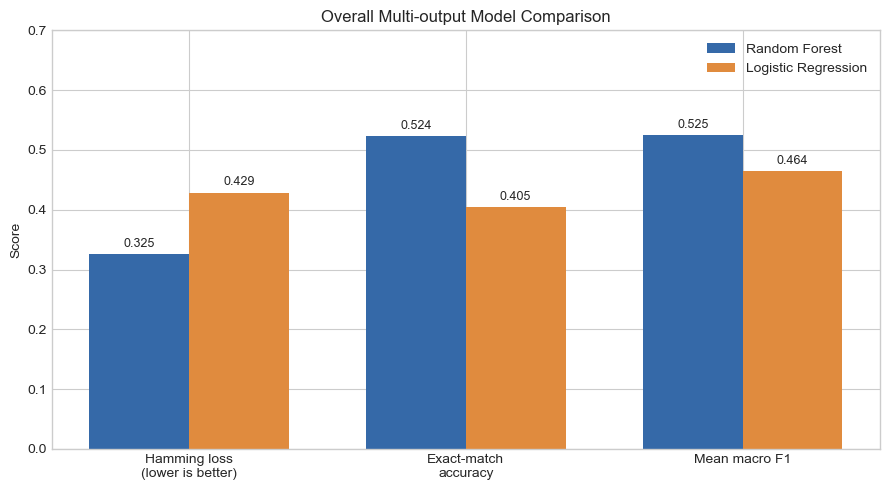

In [14]:
metrics = [
    "Hamming loss",
    "Exact-match accuracy",
    "Mean macro F1",
]

metric_labels = [
    "Hamming loss\n(lower is better)",
    "Exact-match\naccuracy",
    "Mean macro F1",
]

positions = np.arange(len(metrics))
width = 0.36
colours = ["#3569a8", "#e08b3e"]

fig, ax = plt.subplots(figsize=(9, 5))

for index, row in overall_df.iterrows():
    offset = (index - 0.5) * width
    values = row[metrics].astype(float).to_numpy()

    bars = ax.bar(
        positions + offset,
        values,
        width,
        label=row["Model"],
        color=colours[index],
    )

    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)

ax.set_title("Overall Multi-output Model Comparison")
ax.set_ylabel("Score")
ax.set_xticks(positions, metric_labels)
ax.set_ylim(0, 0.70)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### Overall interpretation

Random Forest performs better overall. It has a lower Hamming loss, meaning that it makes fewer incorrect individual label decisions. It also achieves higher exact-match accuracy and mean macro F1. Random Forest is therefore selected as the preferred model for the current prototype.

## 4.3 Per-label results

The following table compares performance separately for `y2`, `y3`, and `y4`. Macro metrics assign equal importance to every class, including rare classes.

In [15]:
label_rows = []

for model_name, result in results.items():
    for label, metric in result["per_label"].items():
        label_rows.append({
            "Model": model_name,
            "Label": label,
            "Classes": metric["n_classes"],
            "Accuracy": metric["accuracy"],
            "Macro precision": metric["precision_macro"],
            "Macro recall": metric["recall_macro"],
            "Macro F1": metric["f1_macro"],
            "Weighted F1": metric["f1_weighted"],
        })

per_label_df = pd.DataFrame(label_rows)
per_label_df = per_label_df.sort_values(
    ["Label", "Model"]
).reset_index(drop=True)

metric_columns = [
    "Accuracy",
    "Macro precision",
    "Macro recall",
    "Macro F1",
    "Weighted F1",
]

display(per_label_df.style.format(
    {column: "{:.3f}" for column in metric_columns}
))

,Model,Label,Classes,Accuracy,Macro precision,Macro recall,Macro F1,Weighted F1
0,Logistic Regression,y2,3,0.714,0.687,0.686,0.685,0.716
1,Random Forest,y2,3,0.738,0.817,0.647,0.662,0.720
2,Logistic Regression,y3,11,0.500,0.375,0.448,0.369,0.514
3,Random Forest,y3,11,0.643,0.499,0.488,0.482,0.650
4,Logistic Regression,y4,14,0.500,0.349,0.400,0.338,0.507
5,Random Forest,y4,14,0.643,0.426,0.455,0.431,0.603


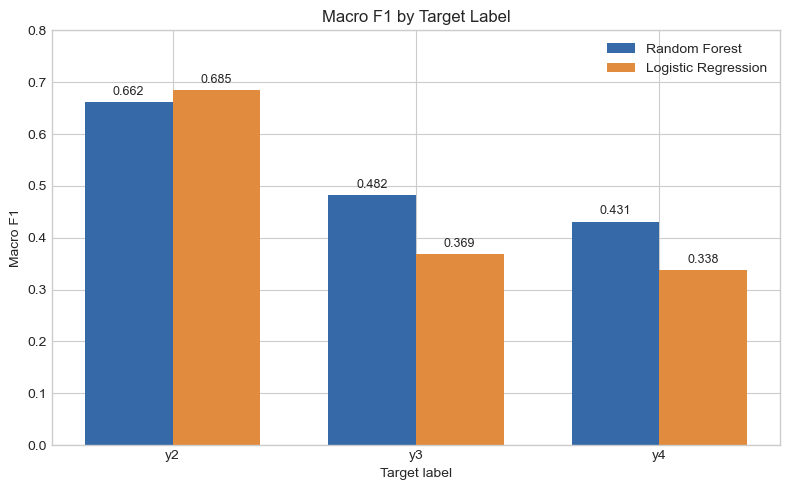

In [16]:
labels = ["y2", "y3", "y4"]
models = list(results)
positions = np.arange(len(labels))
width = 0.36
colours = ["#3569a8", "#e08b3e"]

fig, ax = plt.subplots(figsize=(8, 5))

for index, model_name in enumerate(models):
    model_rows = (
        per_label_df[per_label_df["Model"] == model_name]
        .set_index("Label")
        .loc[labels]
    )

    offset = (index - 0.5) * width

    bars = ax.bar(
        positions + offset,
        model_rows["Macro F1"],
        width,
        label=model_name,
        color=colours[index],
    )

    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)

ax.set_title("Macro F1 by Target Label")
ax.set_xlabel("Target label")
ax.set_ylabel("Macro F1")
ax.set_xticks(positions, labels)
ax.set_ylim(0, 0.8)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### Per-label interpretation

`y2` is the easiest target because it contains only three classes. Performance decreases for `y3` and `y4`, which contain 11 and 14 classes respectively. Random Forest performs substantially better on these more detailed targets. Logistic Regression has a slightly higher macro F1 for `y2`, despite Random Forest having higher `y2` accuracy. This demonstrates why accuracy and macro F1 should be considered together.

## 4.4 Class-imbalance analysis

Weighted F1 gives greater influence to frequent classes, while macro F1 treats every class equally. A large difference between the two metrics indicates that common classes are being classified more successfully than rare classes.

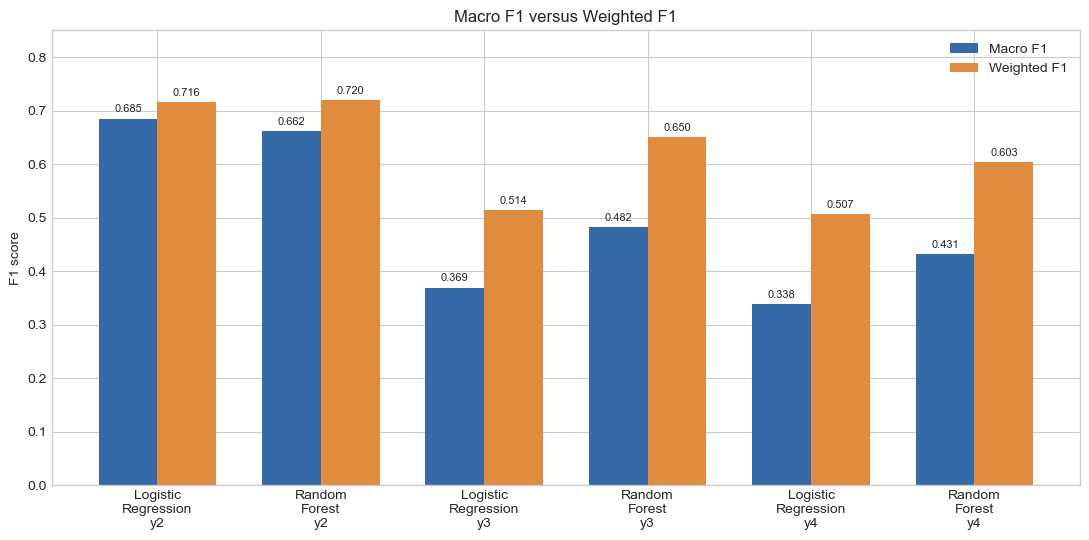

In [17]:
chart_df = per_label_df.copy()
chart_df["Display name"] = (
    chart_df["Model"].str.replace(" ", "\n")
    + "\n"
    + chart_df["Label"]
)

positions = np.arange(len(chart_df))
width = 0.36

fig, ax = plt.subplots(figsize=(11, 5.5))

macro_bars = ax.bar(
    positions - width / 2,
    chart_df["Macro F1"],
    width,
    label="Macro F1",
    color="#3569a8",
)

weighted_bars = ax.bar(
    positions + width / 2,
    chart_df["Weighted F1"],
    width,
    label="Weighted F1",
    color="#e08b3e",
)

ax.bar_label(macro_bars, fmt="%.3f", padding=3, fontsize=8)
ax.bar_label(weighted_bars, fmt="%.3f", padding=3, fontsize=8)

ax.set_title("Macro F1 versus Weighted F1")
ax.set_ylabel("F1 score")
ax.set_xticks(positions, chart_df["Display name"])
ax.set_ylim(0, 0.85)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### Imbalance interpretation

Weighted F1 is higher than macro F1 for most targets. The difference is especially visible for `y3` and `y4`, showing that frequent classes perform reasonably well while rare classes reduce the macro average. Class weighting helps reduce majority-class bias, but it cannot create sufficient learning evidence for classes that have very few training examples.

## 4.5 Random Forest per-class results

The full classification report can be filtered by target. The `y2` results provide a clear example of minority-class behaviour.

In [18]:
rf_report = reports["Random Forest"]

rf_y2 = rf_report[
    (rf_report["label"] == "y2")
    & (~rf_report["class"].isin(["macro avg", "weighted avg"]))
].copy()

display(rf_y2.style.format({
    "precision": "{:.3f}",
    "recall": "{:.3f}",
    "f1": "{:.3f}",
}))

,label,class,precision,recall,f1,support
0,y2,Others,1.000,0.286,0.444,7
1,y2,Problem/Fault,0.650,0.812,0.722,16
2,y2,Suggestion,0.800,0.842,0.821,19


The `Others` class has high precision but low recall. This means that when Random Forest predicts `Others`, it is usually correct, but it misses most of the genuine `Others` messages. This is a typical minority-class failure: the model is conservative about assigning the less frequent class.

## 4.6 Error analysis

The error files contain genuine incorrect predictions from the test set. Each row represents one incorrect target-label decision.

In [19]:
error_summary_rows = []

for model_name, error_df in errors.items():
    counts = error_df["label"].value_counts()

    for label in ["y2", "y3", "y4"]:
        error_summary_rows.append({
            "Model": model_name,
            "Label": label,
            "Errors in saved file": int(counts.get(label, 0)),
        })

error_summary_df = pd.DataFrame(error_summary_rows)
display(error_summary_df)

,Model,Label,Errors in saved file
0,Random Forest,y2,11
1,Random Forest,y3,15
2,Random Forest,y4,15
3,Logistic Regression,y2,12
4,Logistic Regression,y3,21
5,Logistic Regression,y4,17


In [20]:
print("Random Forest error examples")

display(
    errors["Random Forest"][[
        "row_index",
        "text_snippet",
        "label",
        "true",
        "predicted",
    ]].head(15)
)

Random Forest error examples


,row_index,text_snippet,label,true,predicted
0,65,NaN,y2,Others,Problem/Fault
1,68,how do become vip if do saw if it right you have to spend chf every month and spend over chf wanted to ask do get th...,y2,Problem/Fault,Suggestion
2,6,so the campaign name was xmas download and win play pt as you will see in the screenshot will send you and won vouch...,y2,Suggestion,Problem/Fault
3,131,product cloud requests upgrade cloud storage contact full name pavol hete phone numbe contact email address company ...,y2,Suggestion,Problem/Fault
4,63,NaN,y2,Others,Problem/Fault
5,125,this is the mail system at host frasgout his company com m sorry to have to inform you that your message could not b...,y2,Others,Suggestion
6,20,beskrivelse installation fejl kontaktoplysninger,y2,Problem/Fault,Suggestion
7,41,we hope you re doing well description of the issue screenshot or record video of error when issue happened your huaw...,y2,Others,Problem/Fault
8,117,we are bringing you an answer regarding your concern after investigation it seems that you haven purchased the cloud...,y2,Problem/Fault,Suggestion
9,3,description contact information,y2,Suggestion,Problem/Fault


### Error interpretation

The errors show several recurring causes:

- Some messages are phrased as open questions, making faults resemble suggestions or enquiries.
- Related categories share vocabulary, such as VIP promotions and payments.
- Some interactions contain mostly support-agent boilerplate and provide little useful classification evidence.
- Some interaction content becomes empty after preprocessing.
- Classes absent from the training split cannot be learned or predicted reliably.

The most serious observed error is a refund request classified as a payment issue. Refund requests may be time-sensitive and require a specialised queue. Low-confidence predictions and high-risk categories should therefore be routed for human review.

## 4.7 Limitations

- The test set contains only 42 messages, so a small number of changed predictions can noticeably affect the results.
- The evaluation uses a single train/test split rather than cross-validation.
- Stratification is based only on `y2` and does not ensure that rare `y3` and `y4` classes occur in both partitions.
- Some classes occur only in the test split and are impossible for the trained models to predict correctly.
- Missing secondary labels are represented by the `unknown` sentinel.
- Multilingual messages and aggressive boilerplate removal may reduce the available TF-IDF signal.
- Offline metrics do not directly measure operational effects such as routing delays or escalation rates.

## 4.8 Conclusion

Random Forest is the preferred model for the current prototype because it achieves the highest mean macro F1 and exact-match accuracy and the lowest Hamming loss. However, both models perform less effectively on detailed, rare, and unseen classes. Production use should therefore include confidence-based human review, monitoring, and collection of additional labelled examples.

## Optional: export the comparison tables

Run the following cell if CSV versions of the notebook tables are required.

In [21]:
evaluation_output = OUTPUTS / "evaluation"
evaluation_output.mkdir(parents=True, exist_ok=True)

overall_df.to_csv(
    evaluation_output / "overall_model_comparison.csv",
    index=False,
)

per_label_df.to_csv(
    evaluation_output / "per_label_comparison.csv",
    index=False,
)

print(f"Tables saved to {evaluation_output}")

Tables saved to c:\Users\josep\Desktop\CA_Code_Starter\CA_Code_Starter\outputs\evaluation
